<h1 align='center'> Plots de Paridade - Dispersão de Fônons MLFF vs Diferenças Finitas </h1>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_bands(filename: str):
    with open(filename, "r") as f:
        lines: list[str] = f.readlines()

    labels: list[str] = lines[0].strip().split()[1:]
    points = np.array(lines[1].strip().split()[1:], dtype=float)

    data = np.loadtxt(filename, comments="#")
    x = data[:, 0]
    bands = data[:, 1:]

    return labels, points, x, bands


## Sem a inclusão dos modos normais

In [3]:
# Ler os arquivos
labels1, points1, x1, bands1 = read_bands(
    r"../alamode_phonons/01_qe_finite_diff/LDA/zno222_NA3.bands"
)
_, _, _, bands2 = read_bands(
    r"../alamode_phonons/03_mlff_aenetpytorch/LDA/model001/zno_lda_aenet.bands"
)


In [4]:
print(bands1.shape)
print(bands2.shape)


(246, 12)
(246, 12)


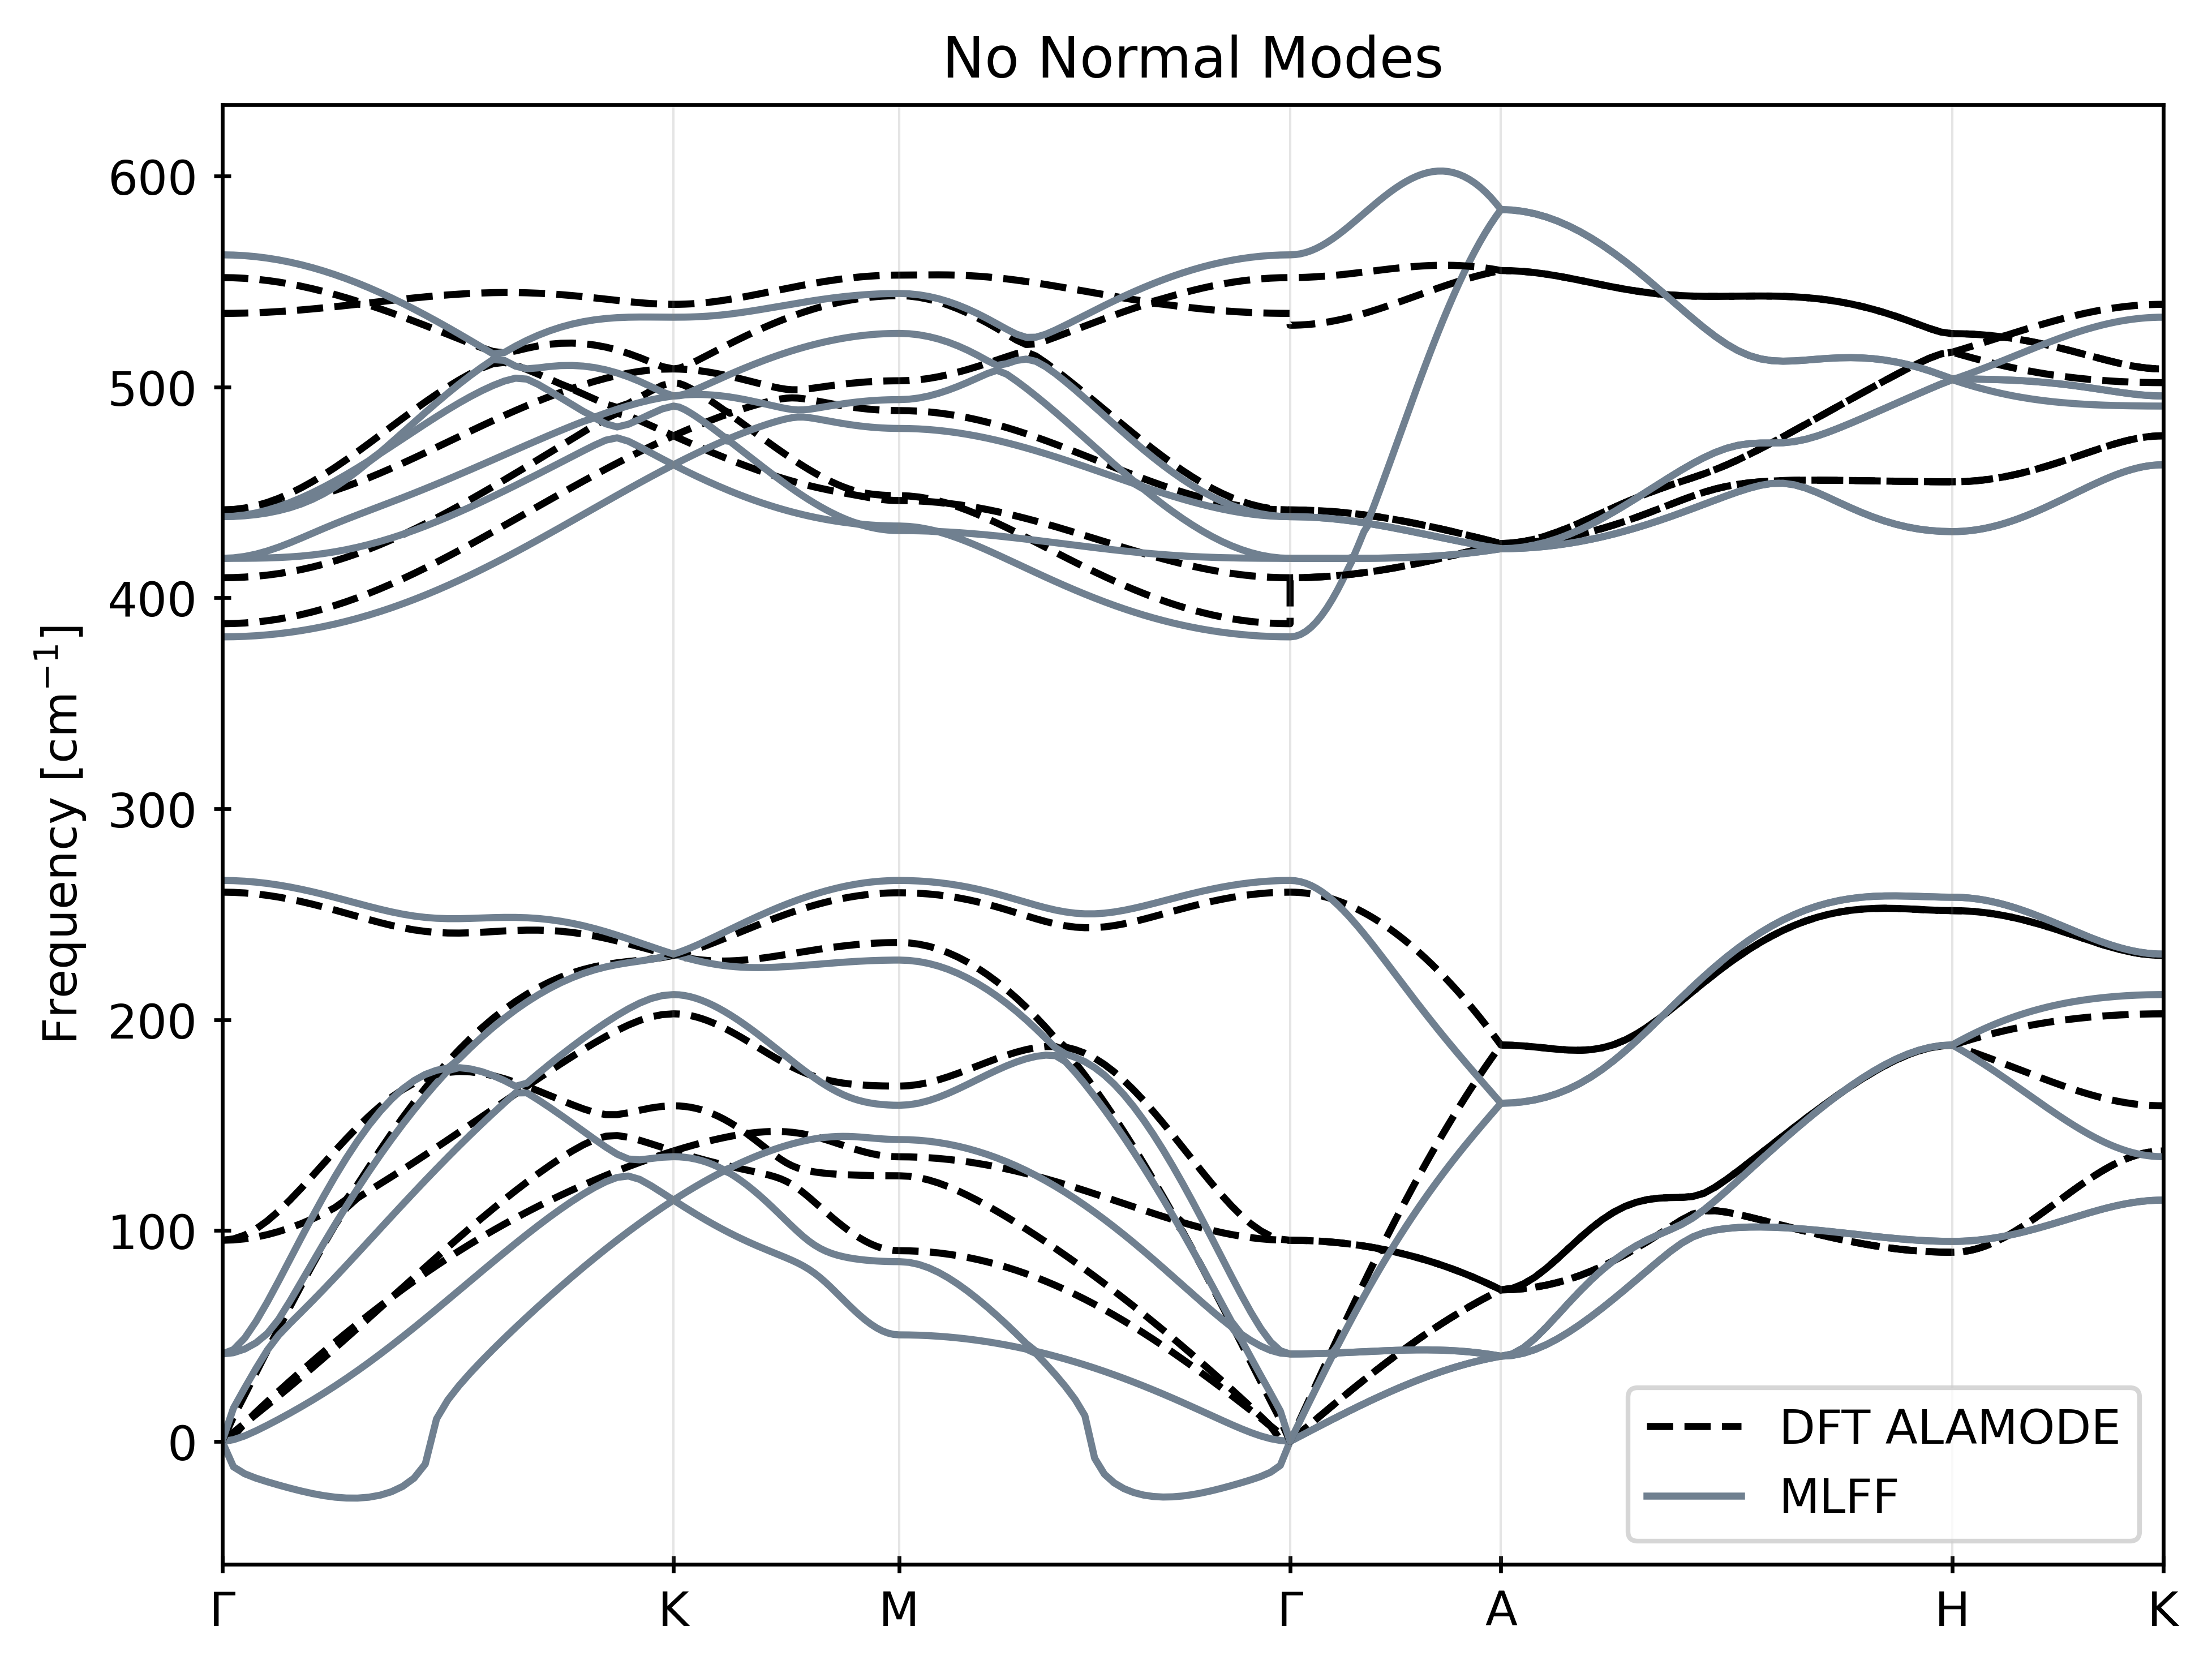

In [5]:
NBANDS = bands1.shape[1]
labels = [r"$\Gamma$" if label == "G" else label for label in labels1]

fig, ax = plt.subplots(dpi=600, layout="constrained")
ax.set_title("No Normal Modes")
ax.tick_params(direction="inout")
ax.set(
    xticks=points1,
    xticklabels=labels,
    xlim=(points1[0], points1[-1]),
    ylabel=r"Frequency [cm$^{-1}$]",
)

for q in range(NBANDS):
    label = "DFT ALAMODE" if q == 0 else ""
    ax.plot(x1, bands1[:, q], color="k", ls="--", label=label)
    label = "MLFF" if q == 0 else ""
    ax.plot(x1, bands2[:, q], color="slategray", ls="-", label=label)

for p in points1:
    ax.axvline(p, color="gray", ls="-", lw=0.5, alpha=0.2)
ax.legend()
plt.show()

# Adicionando modos normais

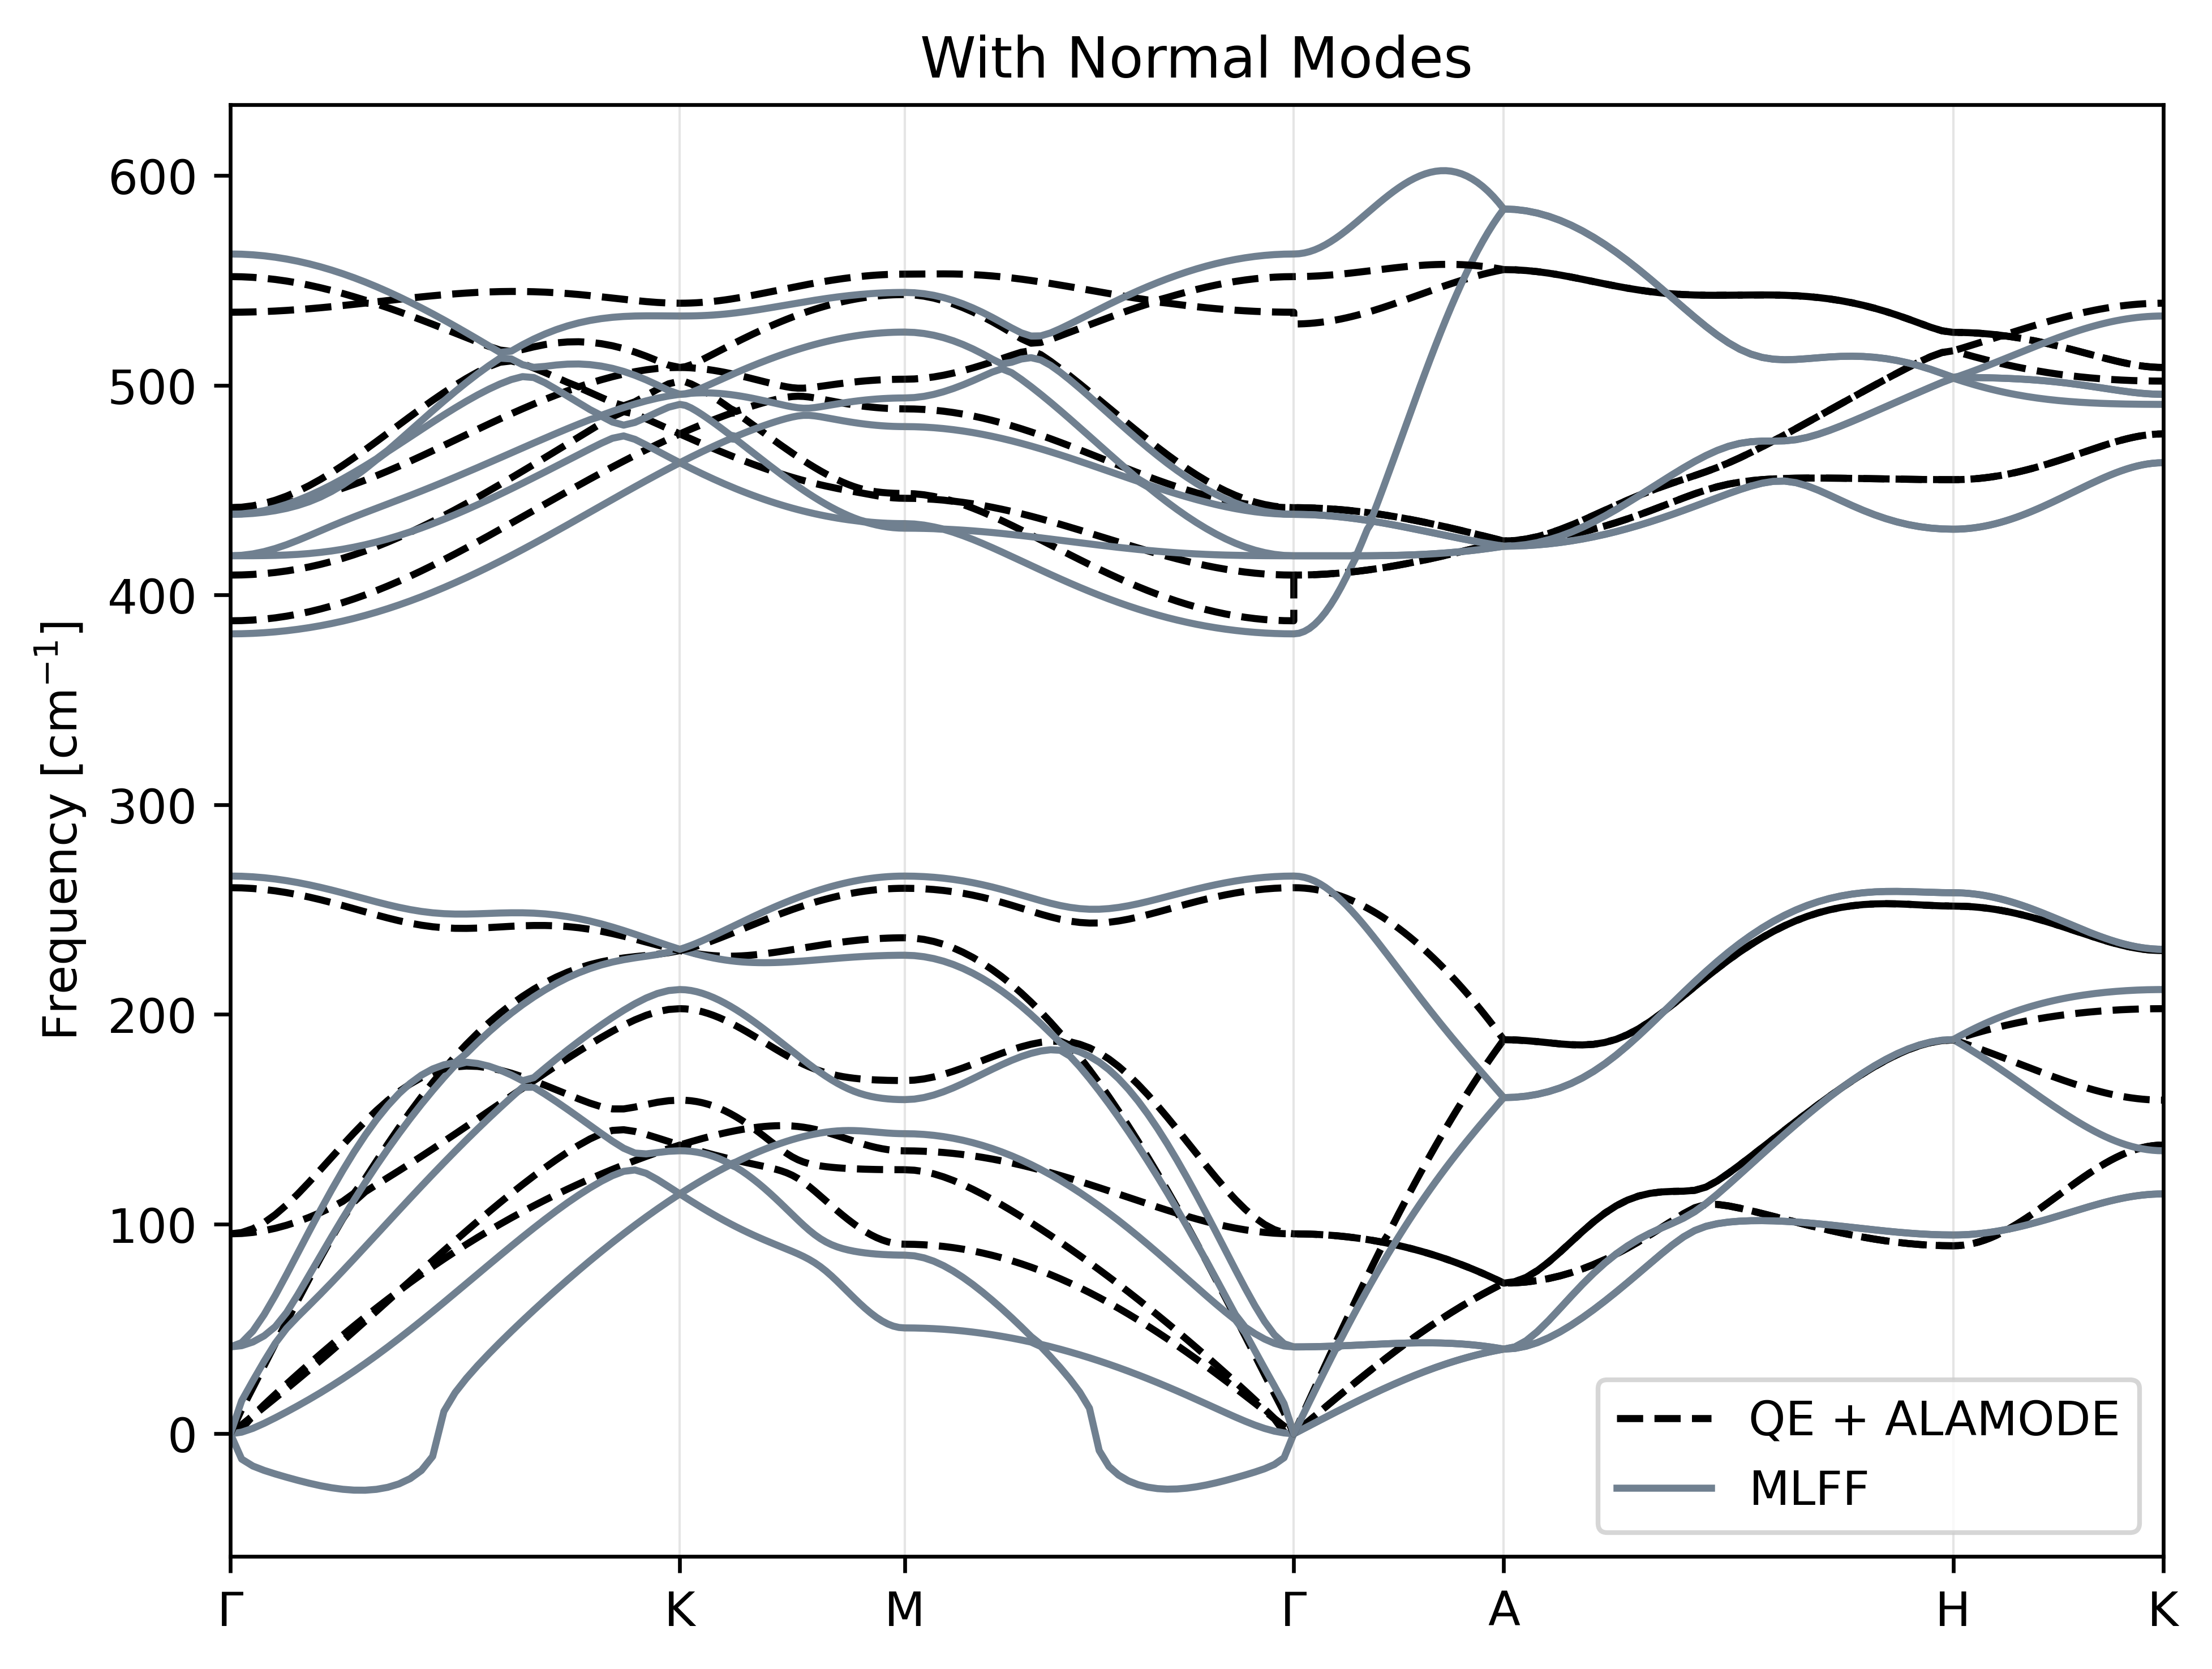

In [6]:
_, _, _, bands3 = read_bands(
    r"../alamode_phonons/03_mlff_aenetpytorch/LDA/model002/zno_lda_aenet.bands"
)

formatted_labels = [r"$\Gamma$" if label == "G" else label for label in labels1]
NBANDS = bands1.shape[1]

fig, ax = plt.subplots(dpi=600, layout="constrained")
ax.set_title("With Normal Modes")
ax.set(
    xticks=points1,
    xticklabels=labels,
    xlim=(points1[0], points1[-1]),
    ylabel=r"Frequency [cm$^{-1}$]",
)

for q in range(NBANDS):
    label_dft = "QE + ALAMODE" if q == 0 else ""
    label_mlff = "MLFF" if q == 0 else ""

    ax.plot(x1, bands1[:, q], color="black", ls="--", label=label_dft)
    ax.plot(x1, bands2[:, q], color="slategray", ls="-", label=label_mlff)

for p in points1:
    plt.axvline(p, color="gray", linestyle="-", lw=0.5, alpha=0.2)
ax.legend()
plt.show()

In [7]:
bands2.shape

(246, 12)

Missing Bands

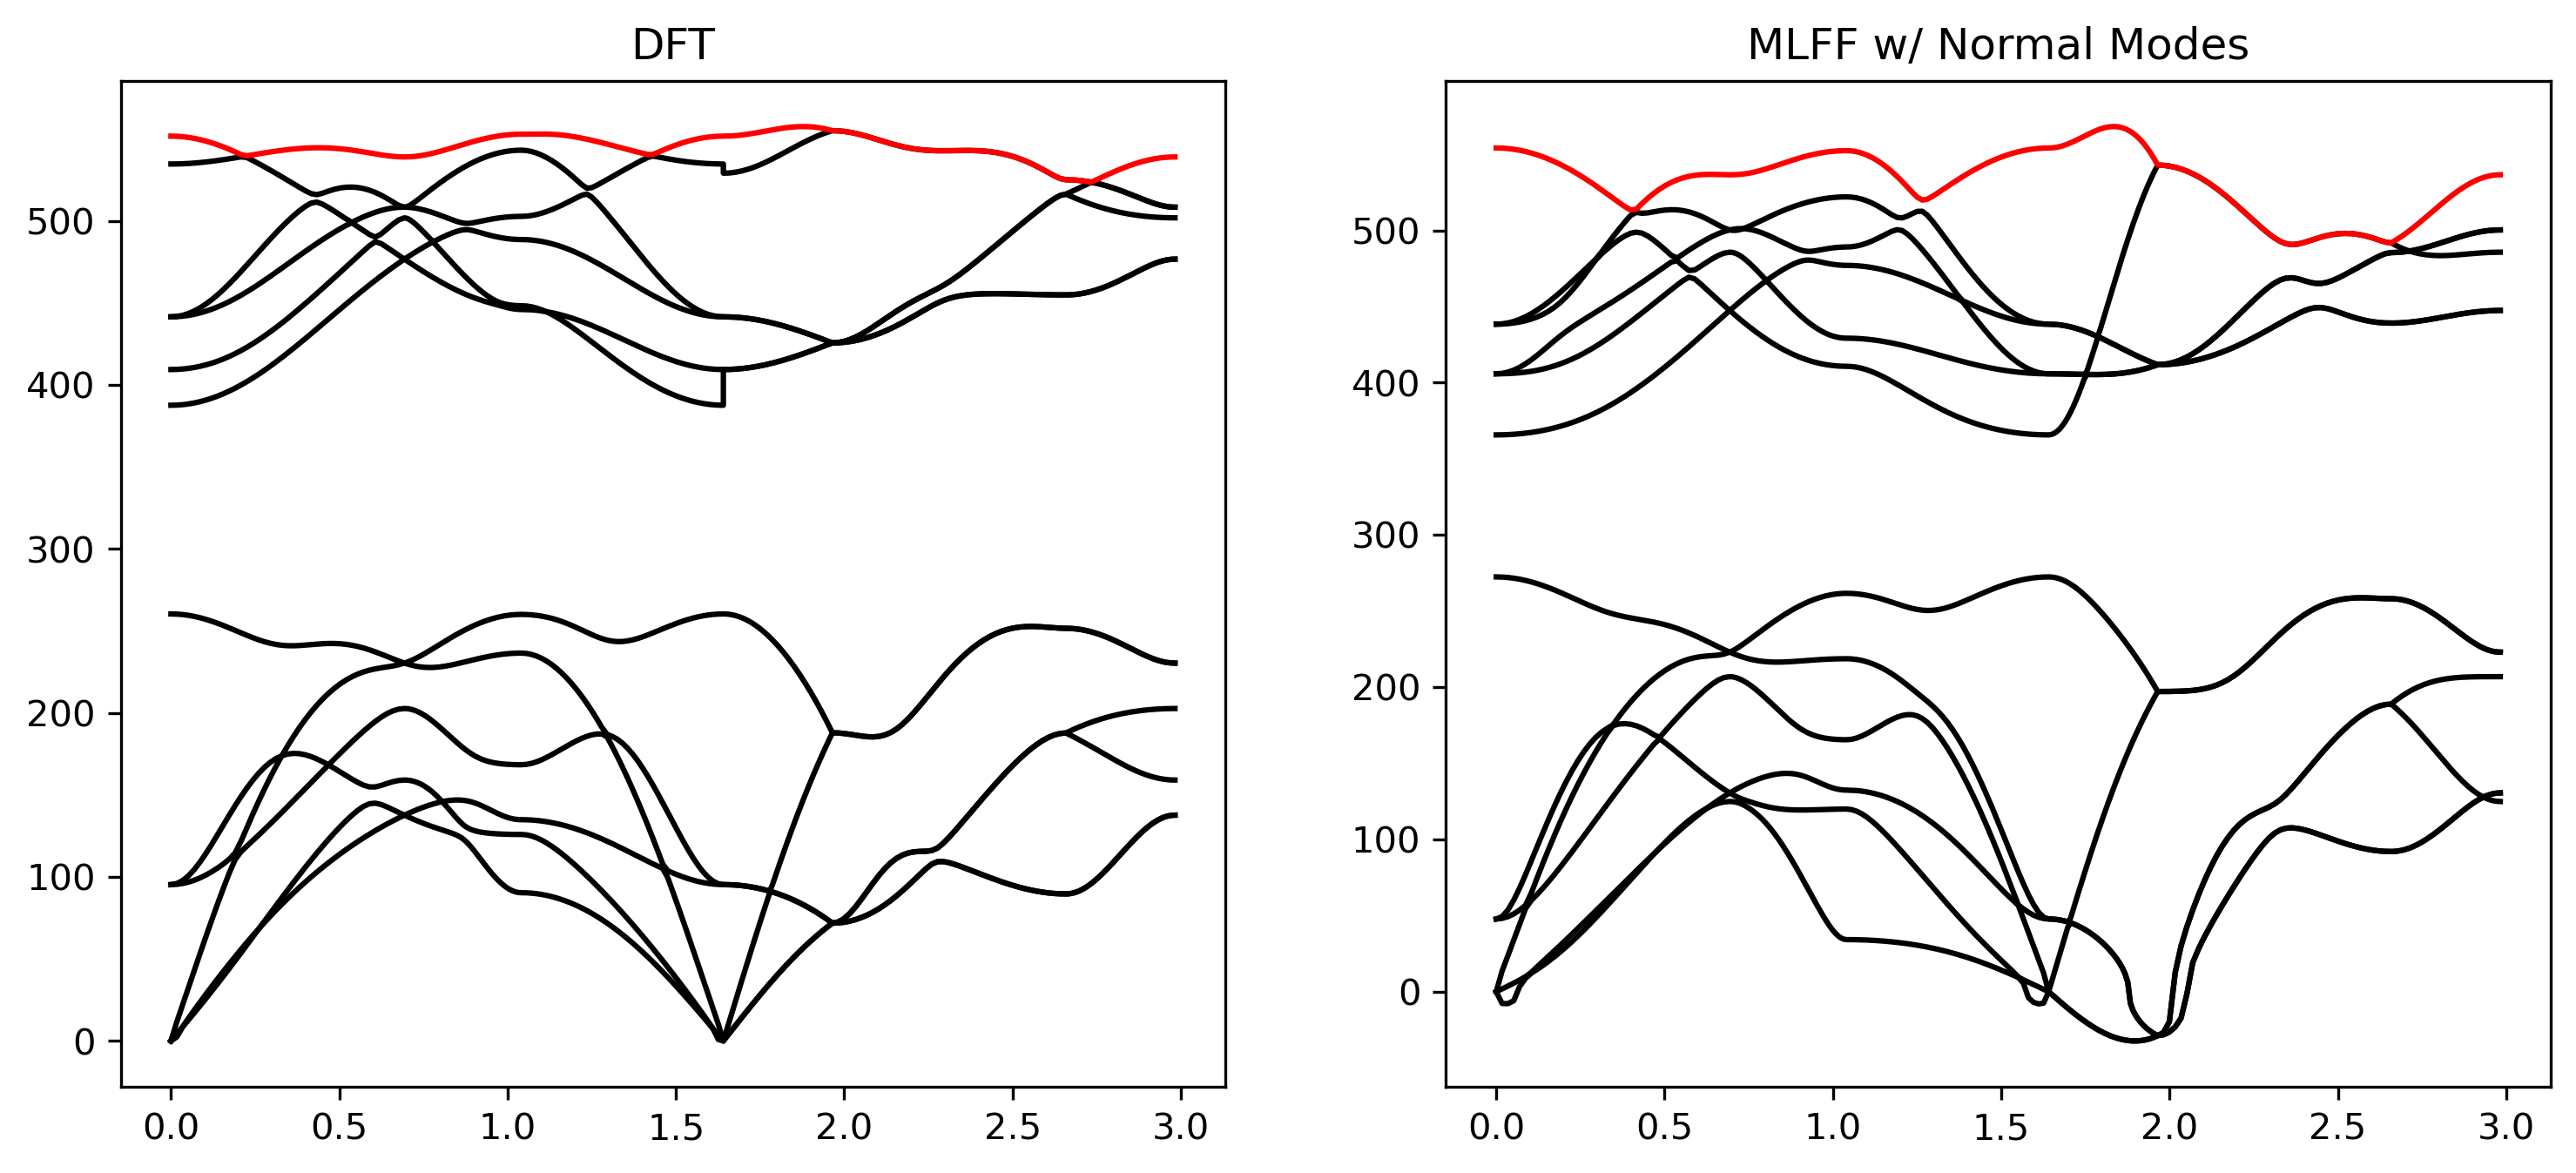

In [8]:
fig, (ax1, ax2) = plt.subplots(figsize=(12, 5), ncols=2, dpi=300)

ax1.set_title("DFT")
ax2.set_title("MLFF w/ Normal Modes")

for i in range(12):
    ax1.plot(x1, bands1[:, i], label=str(i), color="red" if i == 11 else "black")
    ax2.plot(x1, bands3[:, i], label=str(i), color="red" if i == 11 else "black")

plt.show()

Missing Band

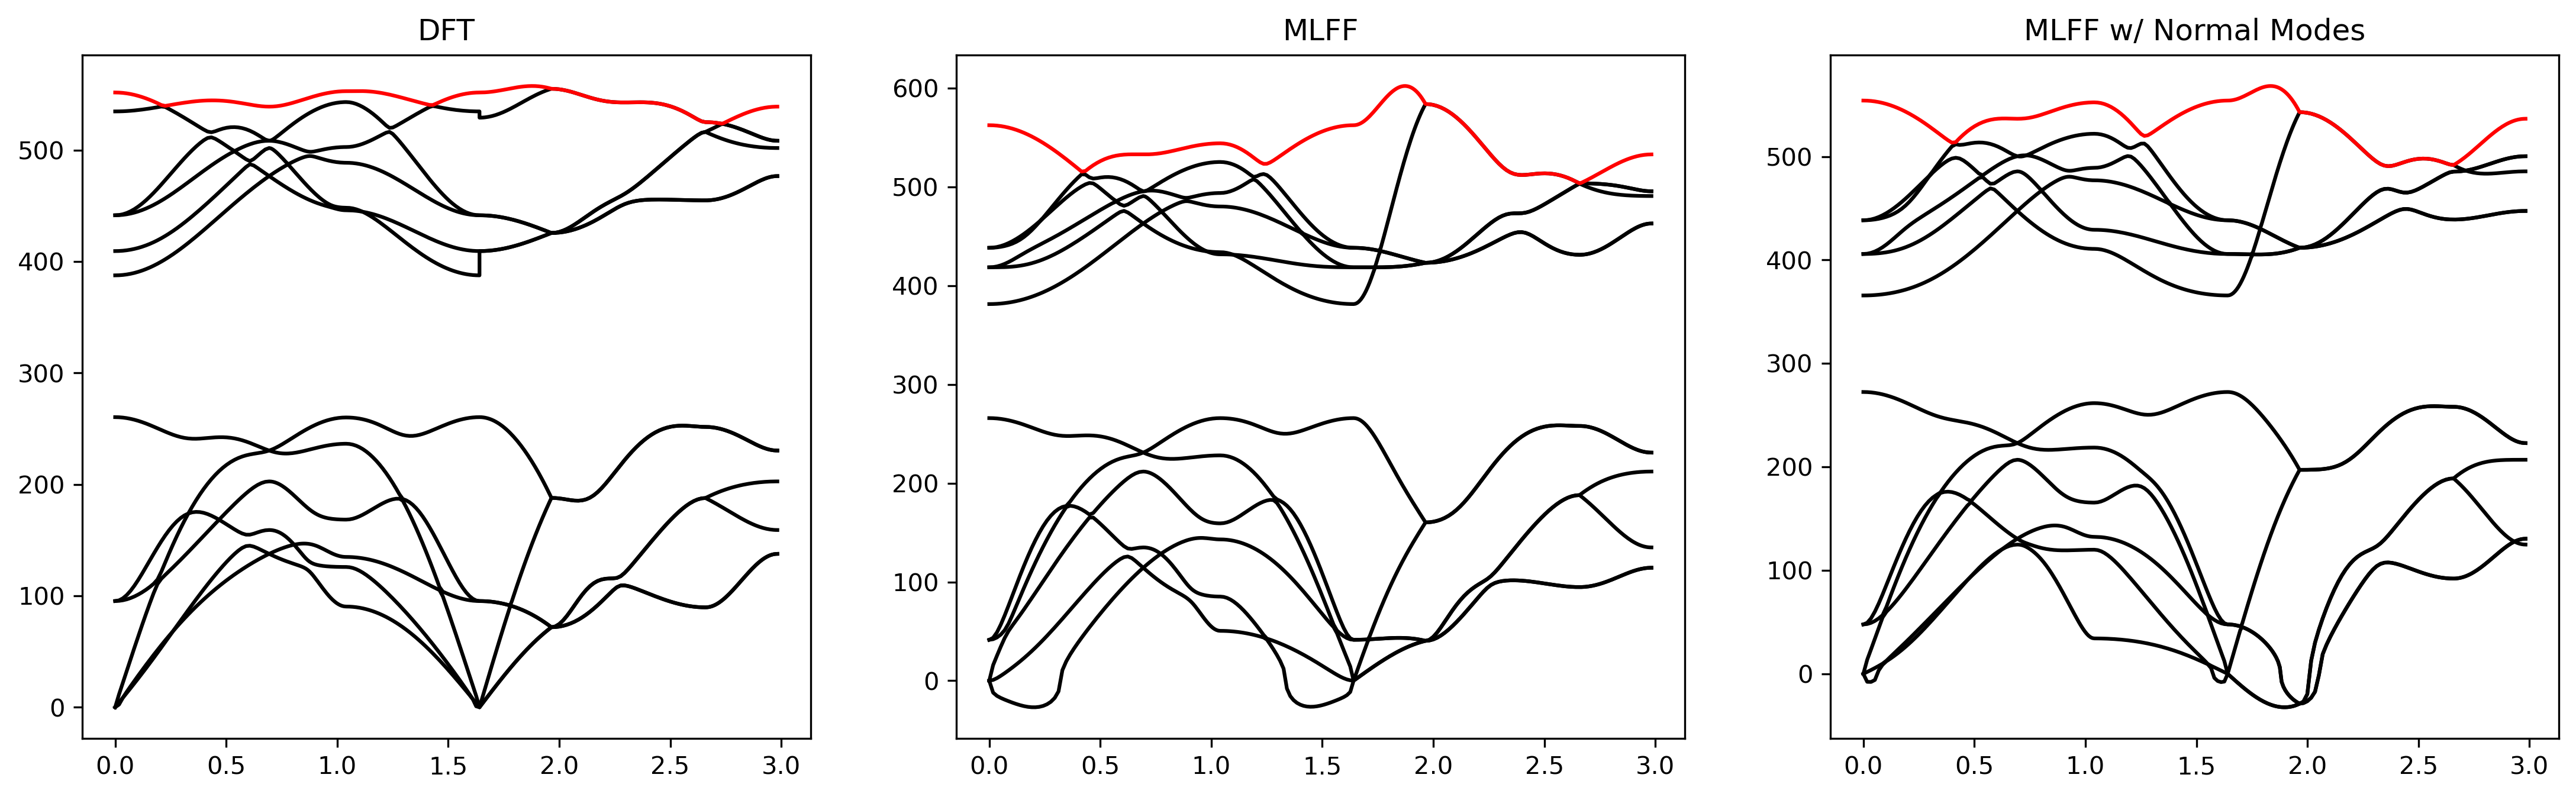

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(18, 5), ncols=3, dpi=300)

ax1.set_title("DFT")
ax2.set_title("MLFF")
ax3.set_title("MLFF w/ Normal Modes")

for i in range(12):
    ax1.plot(x1, bands1[:, i], label=str(i), color="red" if i == 11 else "black")
    ax2.plot(x1, bands2[:, i], label=str(i), color="red" if i == 11 else "black")
    ax3.plot(x1, bands3[:, i], label=str(i), color="red" if i == 11 else "black")

plt.show()

## Zaxis-structure

In [ ]:
_, _, _, bands4 = read_bands("../alamode_phonons/03_mlff_aenetpytorch/LDA/model003/zno_lda_model003.bands")

In [23]:
# Sem frequência negativa no DFT (Graças a Deus)
np.sum(bands1 > 0) == bands1.size

True

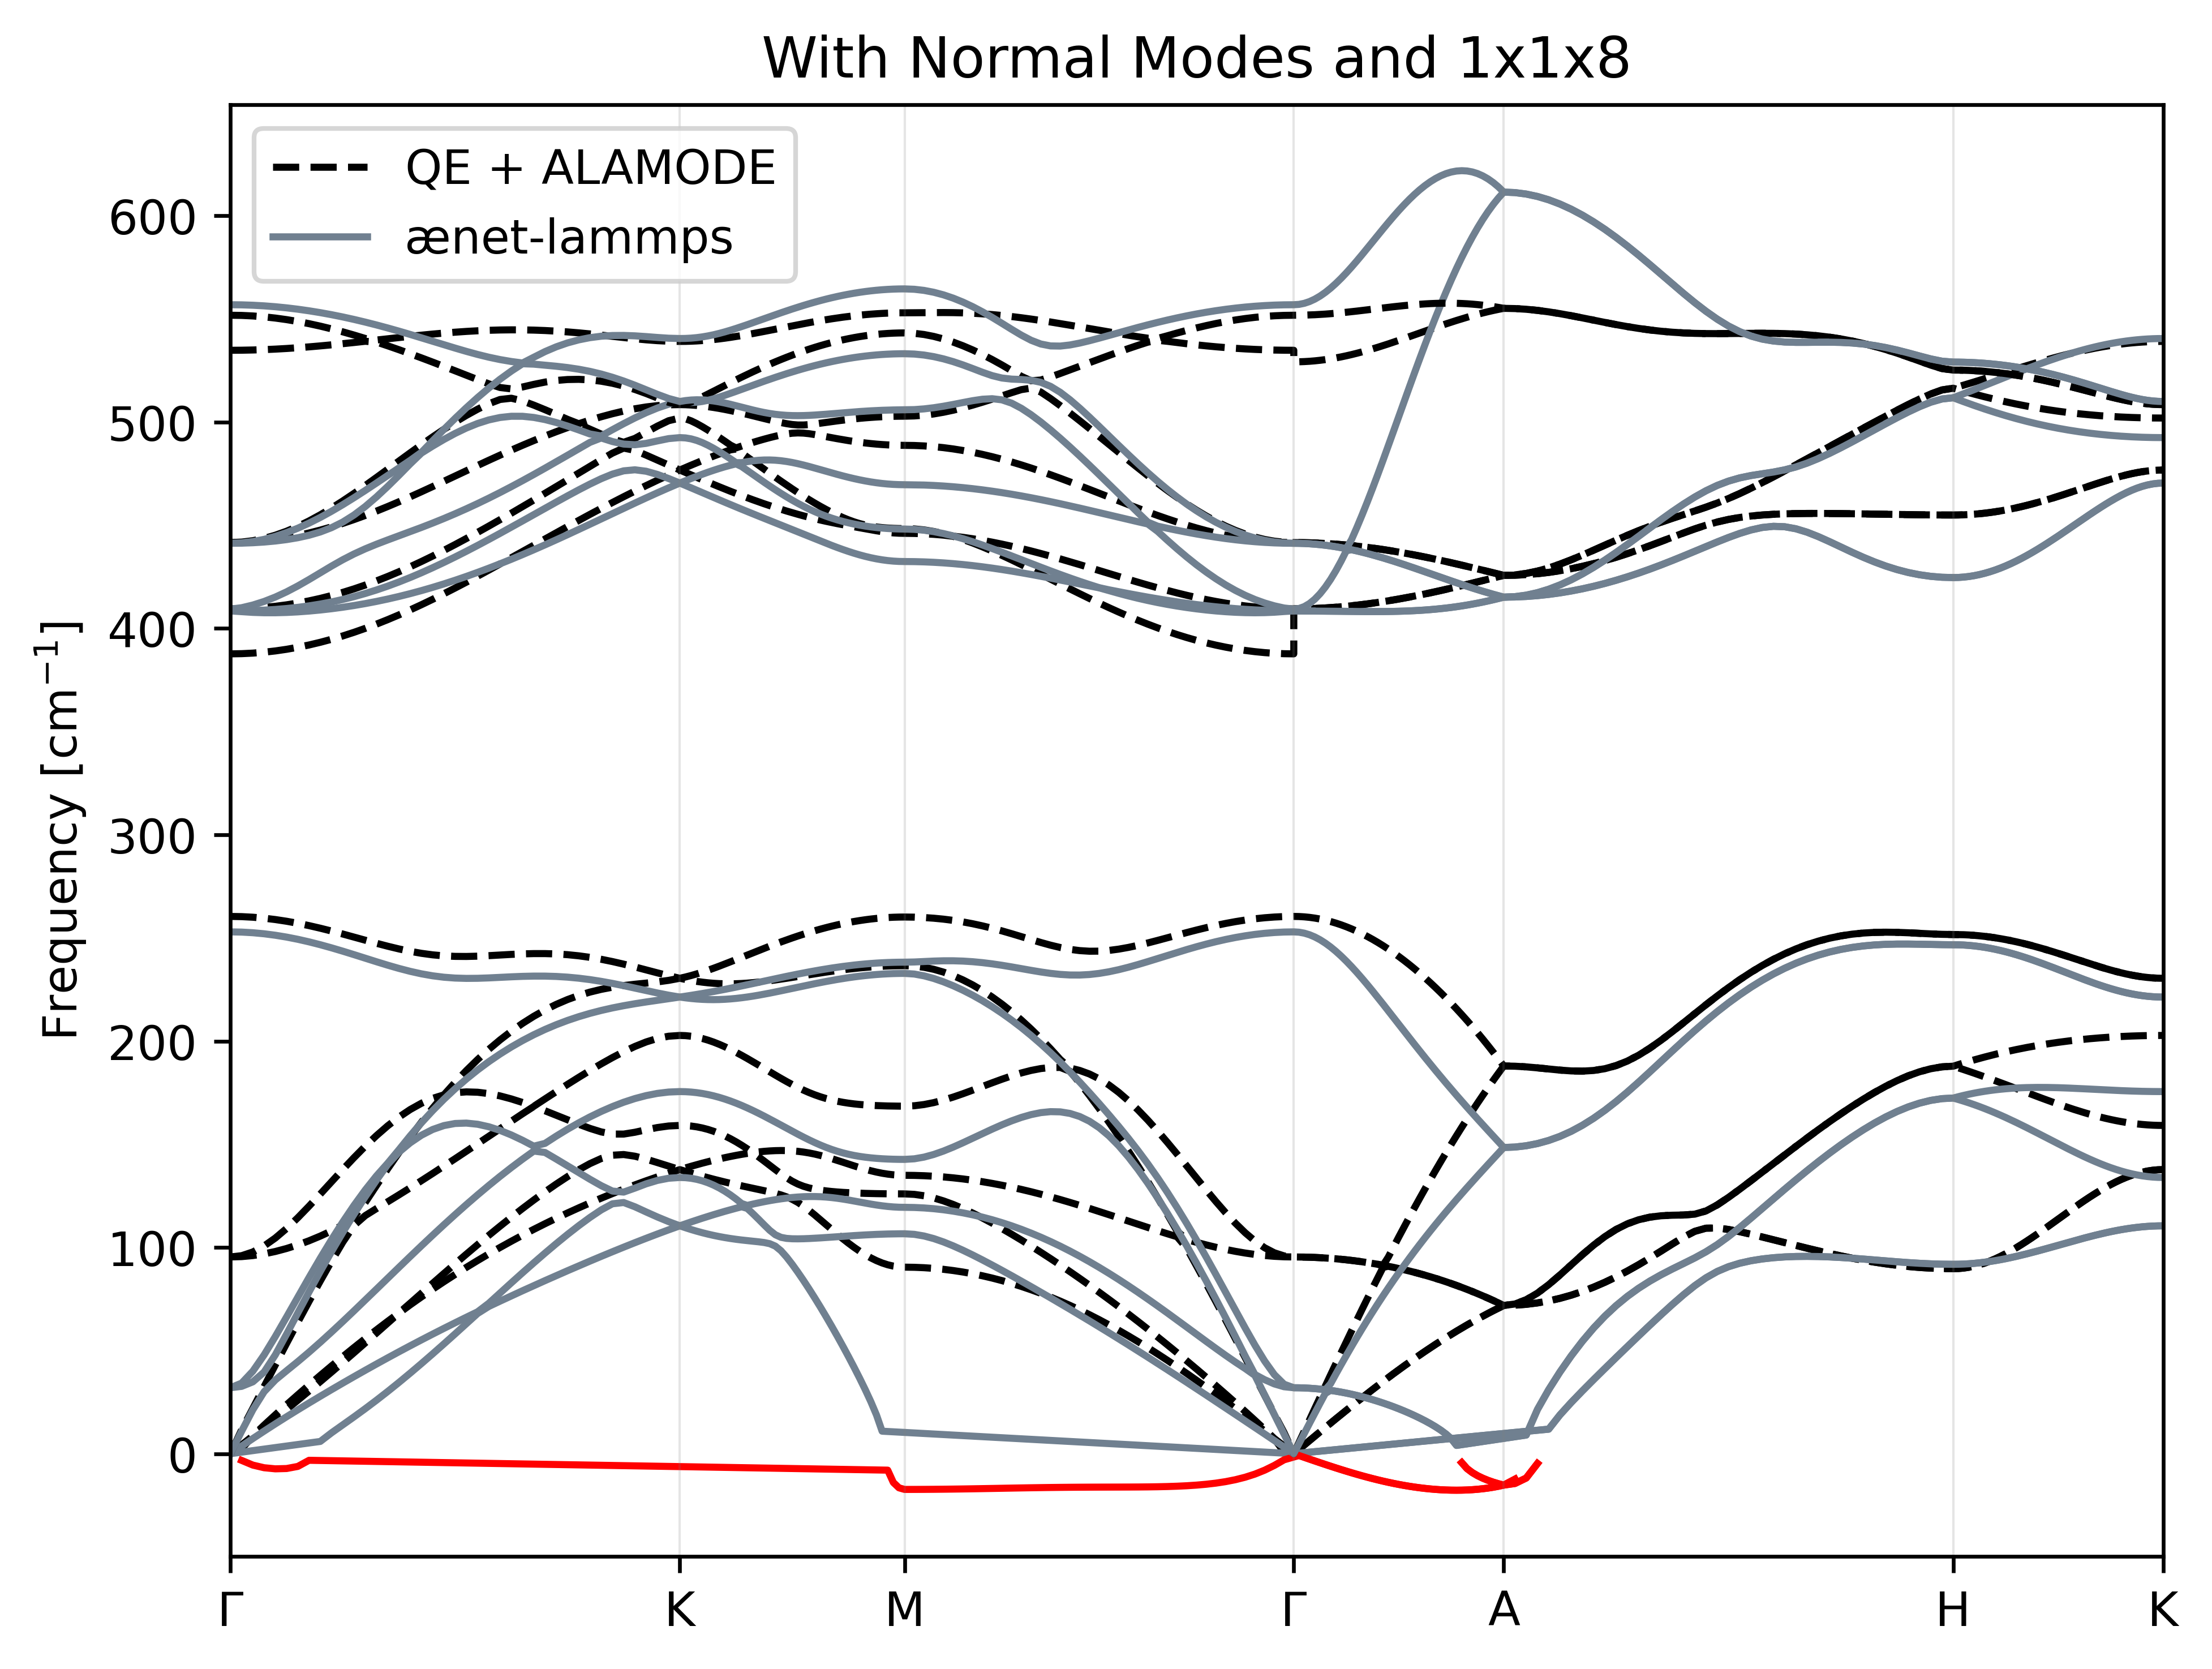

In [ ]:
formatted_labels = [r"$\Gamma$" if label == "G" else label for label in labels1]
NBANDS = bands1.shape[1]

fig, ax = plt.subplots(dpi=600, layout="constrained")
ax.set_title("With Normal Modes and 1x1x8")
ax.set(
    xticks=points1,
    xticklabels=labels,
    xlim=(points1[0], points1[-1]),
    ylabel=r"Frequency [cm$^{-1}$]",
)

for q in range(NBANDS):
    label_dft = "QE + ALAMODE" if q == 0 else ""
    label_mlff = "ænet-lammps" if q == 0 else ""

    # --- DFT ---
    y_dft = bands1[:, q]
    neg_mask_dft = y_dft < 0

    ax.plot(x1[~neg_mask_dft], y_dft[~neg_mask_dft], color="black", ls="--", label=label_dft)
    ax.plot(x1[neg_mask_dft], y_dft[neg_mask_dft], color="pink", ls="--")  # freq negativas no DFT

    # --- MLFF ---
    y_mlff = bands4[:, q]
    neg_mask_mlff = y_mlff < 0

    ax.plot(x1[~neg_mask_mlff], y_mlff[~neg_mask_mlff],color="slategray", ls="-", label=label_mlff)
    ax.plot(x1[neg_mask_mlff], y_mlff[neg_mask_mlff], color="red", ls="-")

for p in points1:
    plt.axvline(p, color="gray", linestyle="-", lw=0.5, alpha=0.2)

ax.legend()
plt.show()

[](https://www.researchgate.net/profile/Paulo-Faria-Junior/publication/257972579/figure/fig1/AS:289135148453900@1445946599175/Usual-a-ZB-and-b-WZ-first-Brillouin-zones-and-their-respective-high-symmetry-points.png)


<div align="center">

| Zona de Brilloun Wurtzita (b) |
|:-:|
| 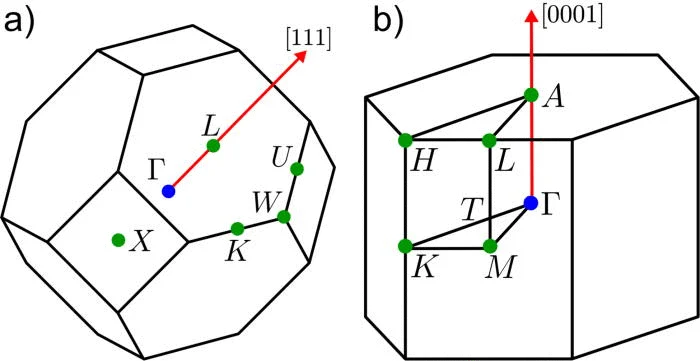 |

</div>